# Notebook 02 — CO₂ Spectral Line Profiles

## Overview
Molecular absorption lines are not infinitely narrow delta functions — physical broadening processes give them characteristic shapes.

This notebook explores:
1. **Doppler (Gaussian) broadening** — due to molecular thermal motion
2. **Pressure (Lorentzian) broadening** — due to molecular collisions
3. **Voigt profile** — the physical convolution of both effects
4. How pressure and temperature control the line widths in the atmosphere


### Doppler Broadening

Doppler broadening arises from the thermal motion of molecules.
Each molecule moves with a random velocity, which causes a Doppler shift
in the absorbed frequency. The resulting spectral line shape is Gaussian:

\begin{equation}
\phi_D(\nu) =
\frac{1}{\Delta\nu_D \sqrt{\pi}}
\exp\!\left(
-\frac{(\nu-\nu_0)^2}{\Delta\nu_D^2}
\right)
\end{equation}

where the Doppler half-width is

\begin{equation}
\Delta\nu_D =
\frac{\nu_0}{c}
\sqrt{\frac{2 k_B T \ln 2}{m}} .
\end{equation}

Here $T$ is the temperature, $m$ is the molecular mass, $k_B$ is the
Boltzmann constant, and $c$ is the speed of light.

### Pressure (Collisional) Broadening

Pressure broadening occurs due to frequent molecular collisions.
These collisions interrupt the absorption process and produce a
Lorentzian (Cauchy) line shape:

\begin{equation}
\phi_L(\nu) =
\frac{\Delta\nu_L/\pi}
{(\nu-\nu_0)^2 + \Delta\nu_L^2}.
\end{equation}

The Lorentzian half-width at half maximum (HWHM) scales with pressure:

\begin{equation}
\Delta\nu_L =
\gamma_{\text{air}}
\left(\frac{P}{P_{\text{ref}}}\right)^{n_{\text{air}}}
\left(\frac{T_{\text{ref}}}{T}\right)^{\delta}.
\end{equation}

Here $\gamma_{\text{air}}$ is the air-broadened half-width coefficient,
$P$ is the pressure, and $n_{\text{air}}$ and $\delta$ are empirical
temperature-scaling exponents.

### Voigt Profile

In the real atmosphere, both Doppler and pressure broadening act
simultaneously. The resulting spectral line shape is the convolution
of the Gaussian and Lorentzian profiles, known as the Voigt profile:

\begin{equation}
\phi_V(\nu) =
\int_{-\infty}^{\infty}
\phi_D(\nu')
\phi_L(\nu-\nu')
\, d\nu'.
\end{equation}

Efficient numerical computation of the Voigt profile is typically
performed using the Faddeeva (Humlíček) complex error function.

### Absorption Cross Section

The total absorption cross section at wavenumber $\nu$ is obtained
by summing the contributions from all molecular transitions:

\begin{equation}
\sigma(\nu) =
\sum_i S_i \, \phi_{V,i}(\nu),
\end{equation}

where $S_i$ is the line strength of the $i$-th transition.

Below we illustrate the physical processes that determine the **shape and width of molecular absorption lines in the atmosphere**. In satellite remote sensing, the precise structure of these spectral lines determines how accurately atmospheric gases such as CO₂ can be measured.

The analysis investigates three major aspects of atmospheric spectroscopy:

1. Line broadening due to temperature and pressure
2. Formation of Gaussian, Lorentzian, and Voigt spectral profiles
3. Evolution of spectral line shapes with atmospheric altitude
4. Construction of a multi-line CO₂ absorption spectrum


In [11]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
import matplotlib.pyplot as plt
from spectroscopy import (
    doppler_hwhm,
    lorentz_hwhm,
    gaussian_profile,
    lorentz_profile,
    voigt_profile_func,
    absorption_cross_section,
    demo_line_profiles,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Line Width vs Temperature and Pressure

Let's explore how Doppler and Lorentzian widths vary through the atmosphere.

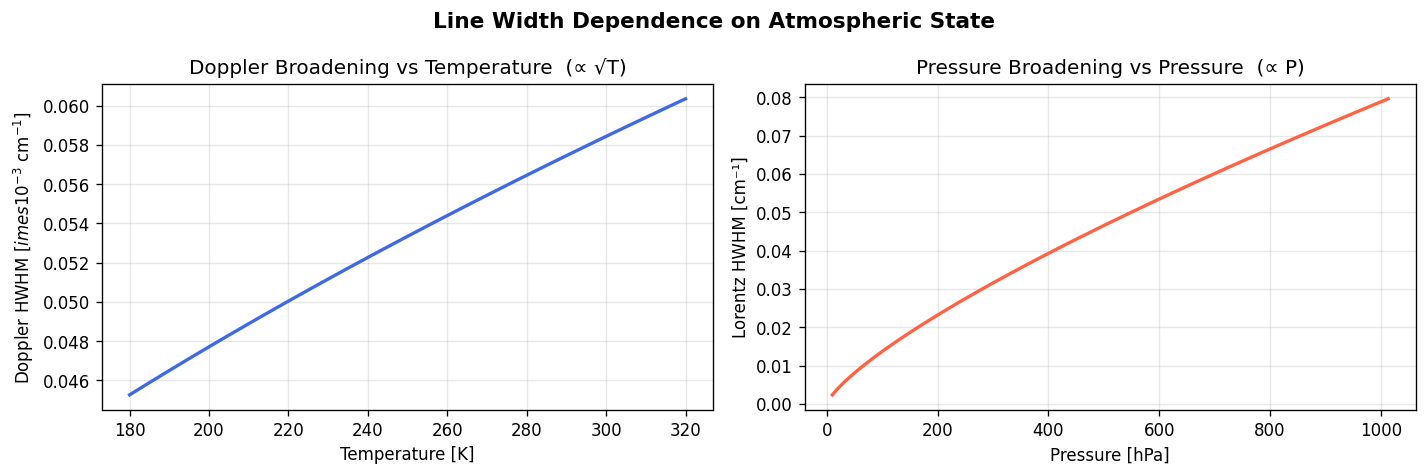

In [12]:
nu0 = 6250.0   # cm⁻¹  (1.6 µm CO₂ band)

# --- Temperature dependence (Doppler) ---
temps = np.linspace(180, 320, 100)      # temperature range from 180 K to 320 K (100 data points)
dnu_D = np.array([doppler_hwhm(nu0, T) for T in temps])

# --- Pressure dependence (Lorentz) at T=250 K ---
pressures = np.linspace(1000, 101325, 100)
dnu_L = np.array([lorentz_hwhm(0.07, P, 250.0) for P in pressures])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(temps, dnu_D * 1000, color='royalblue', lw=2)
ax1.set_xlabel('Temperature [K]'); 
ax1.set_ylabel('Doppler HWHM [$ \times 10^{-3}$ cm$^{-1}$]')
ax1.set_title('Doppler Broadening vs Temperature  (∝ √T)')
ax1.grid(True, alpha=0.3)

ax2.plot(pressures / 100, dnu_L, color='tomato', lw=2)
ax2.set_xlabel('Pressure [hPa]'); ax2.set_ylabel('Lorentz HWHM [cm⁻¹]')
ax2.set_title('Pressure Broadening vs Pressure  (∝ P)')
ax2.grid(True, alpha=0.3)

plt.suptitle('Line Width Dependence on Atmospheric State', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/02a_linewidths.png', dpi=150, bbox_inches='tight')
plt.show()

The figure examines how atmospheric conditions influence spectral line broadening. Two primary physical mechanisms determine line width.

- **Doppler Broadening (Temperature Dependence):** Doppler broadening results from the thermal motion of molecules. Because molecules move randomly at different velocities, the observed absorption frequency is shifted due to the Doppler effect. The Doppler half-width is proportional to the square root of temperature:

$$
\Delta \nu_D \propto \sqrt{T}
$$

The left panel shows that as temperature increases from **180 K to 320 K**, the Doppler width gradually increases. This reflects the increased molecular velocity at higher temperatures.

Doppler broadening dominates in the **upper atmosphere**, where pressure is low and molecular collisions are rare.

- **Pressure Broadening (Collision Broadening):** Pressure broadening arises from collisions between molecules, which perturb the energy levels of absorbing molecules and broaden the spectral line. The Lorentz half-width scales approximately linearly with pressure:

$$
\Delta \nu_L \propto P
$$

The right panel shows that increasing pressure significantly increases the Lorentz line width. This effect is strongest in the **lower atmosphere**, where molecular collisions occur frequently.


## 2. Comparing Profile Shapes

Compare the Gaussian, Lorentzian, and Voigt profiles at a representative atmospheric level.

At T=250.0 K, P=500 hPa:
  Doppler HWHM  Δν_D = 0.00005 cm⁻¹
  Lorentz HWHM  Δν_L = 0.04653 cm⁻¹
  Voigt parameter η  = 0.999
  → Profile is pressure-dominated


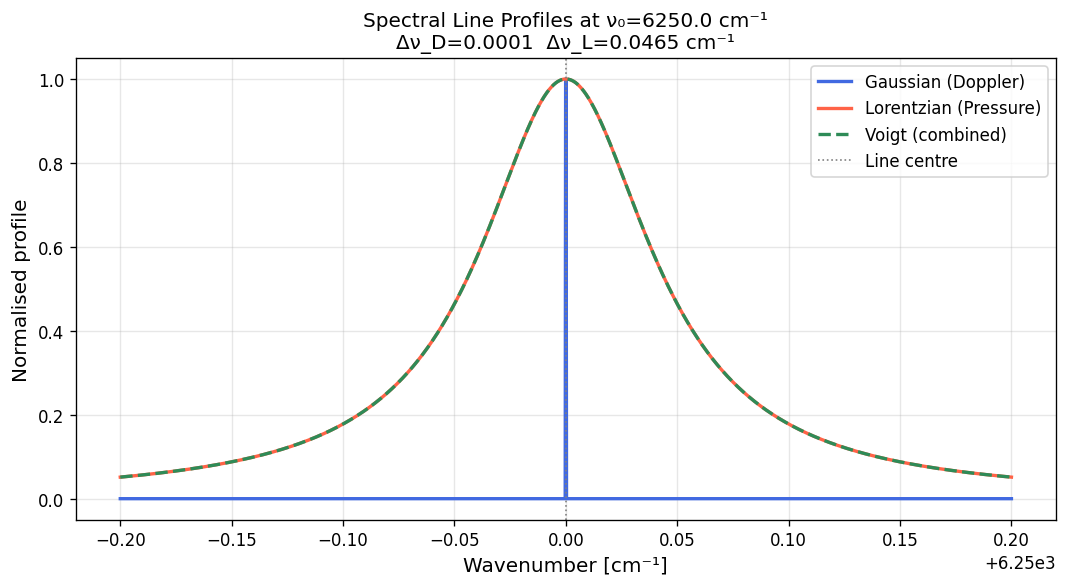

In [13]:
# Mid-troposphere conditions
T = 250.0    # K
P = 50000.0  # Pa (500 hPa)

dnu_D = doppler_hwhm(nu0, T)
dnu_L = lorentz_hwhm(0.07, P, T)

print(f'At T={T} K, P={P/100:.0f} hPa:')
print(f'  Doppler HWHM  Δν_D = {dnu_D:.5f} cm⁻¹')
print(f'  Lorentz HWHM  Δν_L = {dnu_L:.5f} cm⁻¹')
print(f'  Voigt parameter η  = {dnu_L/(dnu_D+dnu_L):.3f}')
print(f'  → Profile is {"pressure-dominated" if dnu_L > dnu_D else "Doppler-dominated"}')

nu_zoom = np.linspace(6249.8, 6250.2, 2000)
demo_line_profiles(nu_zoom, nu0, dnu_D, dnu_L,
                   savefig='../figures/02b_line_profiles.png')

This image compares the fundamental spectral line shapes used in atmospheric spectroscopy. Three line profiles are shown:

1. **Gaussian Profile:** The Gaussian profile represents Doppler broadening caused by molecular thermal motion.

Characteristics:

* symmetric bell-shaped curve
* narrow wings
* dominant in the upper atmosphere


2. **Lorentzian Profile:** The Lorentzian profile represents pressure broadening due to molecular collisions.

Characteristics:

* sharper central peak
* very broad wings
* dominant in the lower atmosphere

3. **Voigt Profile:** The Voigt profile is the convolution of Gaussian and Lorentzian profiles and represents the **real atmospheric spectral line shape**.

$$
\phi_V(\nu) = \phi_G(\nu) * \phi_L(\nu)
$$

This combined profile accurately describes atmospheric absorption lines measured by satellite spectrometers.

The figure demonstrates that the Voigt profile retains the central Gaussian shape while incorporating the extended Lorentzian wings.


## 3. Profile Evolution with Altitude

In the upper atmosphere, pressure drops and the profile transitions from Lorentzian to Gaussian.

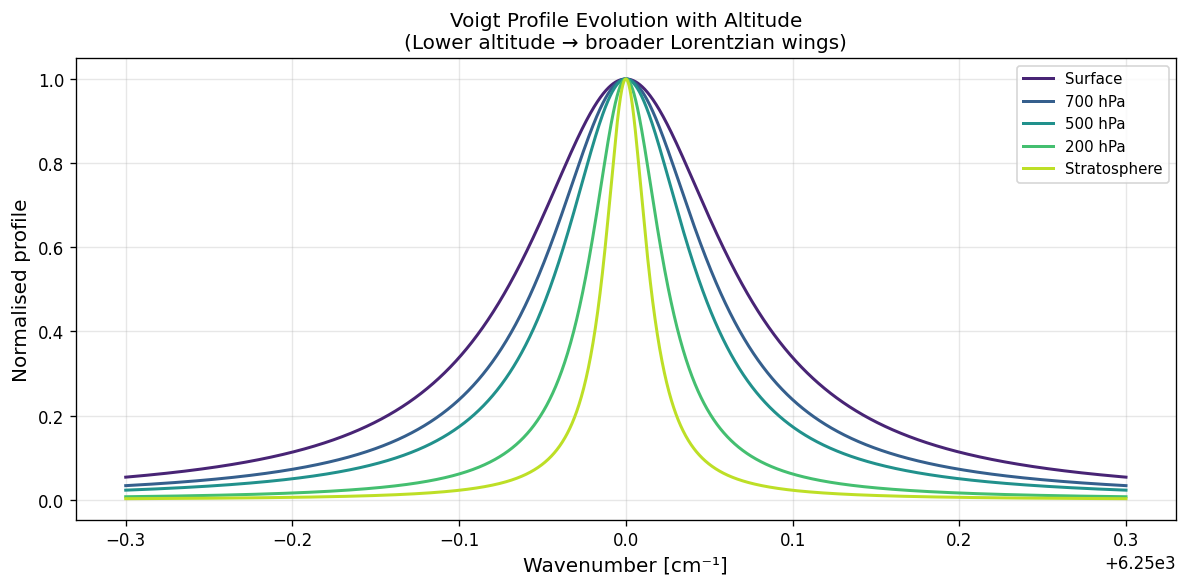

In [4]:
# Representative levels from surface to stratosphere
levels = [
    ('Surface',       101325, 288),
    ('700 hPa',        70000, 275),
    ('500 hPa',        50000, 255),
    ('200 hPa',        20000, 220),
    ('Stratosphere',   10000, 218),
]

nu_zoom = np.linspace(6249.7, 6250.3, 3000)
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(levels)))

for (label, P, T), col in zip(levels, colors):
    dnu_D_i = doppler_hwhm(nu0, T)
    dnu_L_i = lorentz_hwhm(0.07, P, T)
    phi_V   = voigt_profile_func(nu_zoom, nu0, dnu_D_i, dnu_L_i)
    ax.plot(nu_zoom, phi_V / phi_V.max(), color=col, lw=1.8, label=f'{label}')

ax.set_xlabel('Wavenumber [cm⁻¹]', fontsize=12)
ax.set_ylabel('Normalised profile', fontsize=12)
ax.set_title('Voigt Profile Evolution with Altitude\n(Lower altitude → broader Lorentzian wings)', fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/02c_profile_altitude.png', dpi=150, bbox_inches='tight')
plt.show()

This image illustrates how spectral line shapes change with atmospheric altitude.

Five atmospheric layers are considered:

* Surface
* 700 hPa
* 500 hPa
* 200 hPa
* Stratosphere

As altitude increases:

* atmospheric pressure decreases
* molecular collisions become less frequent
* pressure broadening weakens

This produces narrower spectral lines with weaker Lorentzian wings.

Near the surface, strong pressure broadening creates wide spectral features with extended wings. At higher altitudes, the spectral lines become increasingly narrow and Doppler-dominated.

This altitude-dependent line shape is critical for satellite retrieval algorithms, which use it to infer the vertical distribution of atmospheric gases.


## 4. Multi-Line Cross Section

Real CO₂ spectra consist of many overlapping absorption lines — the absorption cross section is their superposition.

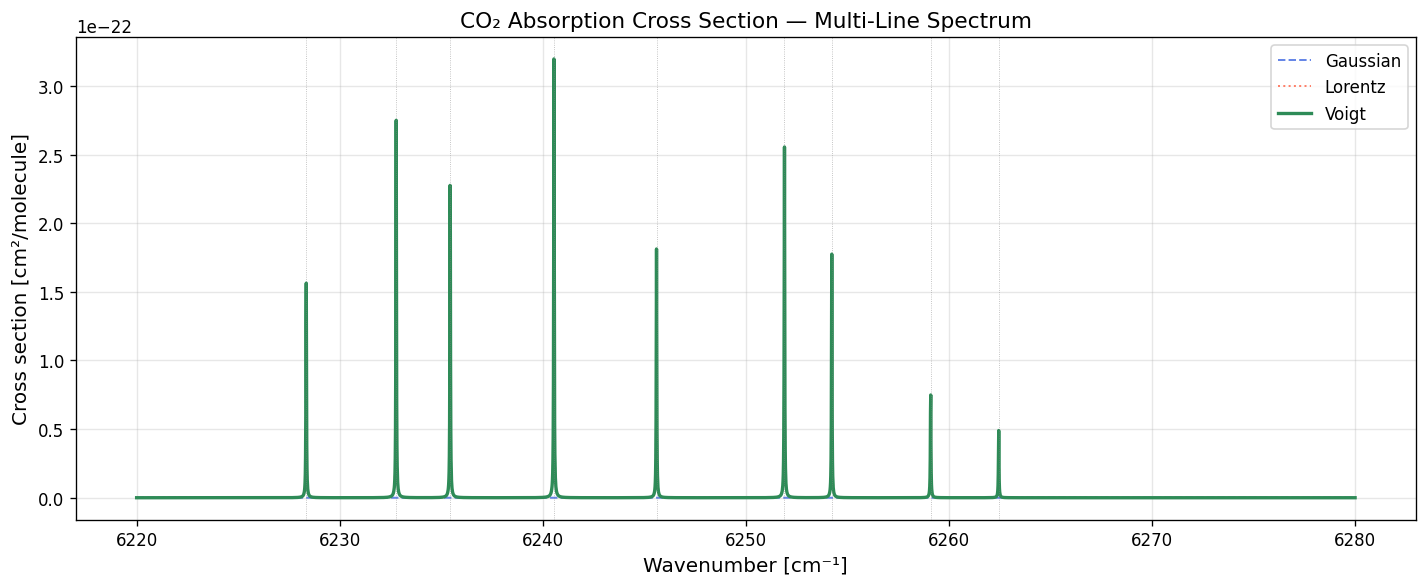

In [5]:
nu = np.linspace(6220, 6280, 5000)

# Synthetic CO₂ line list (representative values)
line_pos = np.array([6228.35, 6232.78, 6235.44, 6240.55, 6245.60,
                     6251.90, 6254.23, 6259.10, 6262.45])
line_str = np.array([7.9e-24, 1.35e-23, 1.2e-23, 1.55e-23, 8.7e-24,
                     1.25e-23, 8.5e-24, 3.8e-24, 2.4e-24])

dnu_D = doppler_hwhm(6250.0, T)
dnu_L = lorentz_hwhm(0.07, P, T)

xsec_voigt   = absorption_cross_section(nu, line_pos, line_str, dnu_D, dnu_L, 'voigt')
xsec_gauss   = absorption_cross_section(nu, line_pos, line_str, dnu_D, dnu_L, 'gaussian')
xsec_lorentz = absorption_cross_section(nu, line_pos, line_str, dnu_D, dnu_L, 'lorentz')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(nu, xsec_gauss,   '--', color='royalblue', lw=1.2, label='Gaussian', alpha=0.8)
ax.plot(nu, xsec_lorentz, ':',  color='tomato',    lw=1.2, label='Lorentz',  alpha=0.8)
ax.plot(nu, xsec_voigt,         color='seagreen',  lw=2.0, label='Voigt')

# Mark line positions
for nu_i in line_pos:
    ax.axvline(nu_i, color='gray', lw=0.5, ls=':', alpha=0.6)

ax.set_xlabel('Wavenumber [cm⁻¹]', fontsize=12)
ax.set_ylabel('Cross section [cm²/molecule]', fontsize=12)
ax.set_title('CO₂ Absorption Cross Section — Multi-Line Spectrum', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/02d_multiline_xsec.png', dpi=150, bbox_inches='tight')
plt.show()


---

# Figure 4 — Multi-Line CO₂ Absorption Spectrum

The final figure constructs a simplified CO₂ absorption spectrum using multiple spectral lines.

Each vertical peak corresponds to a molecular transition in the CO₂ molecule. The combined spectrum represents a realistic absorption band within the **1.6 µm shortwave infrared region**, commonly used for satellite CO₂ measurements.

Three spectral models are compared:

* Gaussian (pure Doppler broadening)
* Lorentzian (pure pressure broadening)
* Voigt (combined broadening)

The Voigt profile provides the most realistic representation of atmospheric absorption features.

The multi-line spectrum demonstrates how many closely spaced molecular transitions combine to produce the absorption bands observed by satellite instruments.

---

# Scientific Interpretation

These simulations reproduce the fundamental spectroscopy that determines how CO₂ absorption appears in atmospheric spectra.

Key insights include:

* Temperature controls Doppler broadening through molecular velocity.
* Pressure controls collision broadening through molecular interactions.
* Real atmospheric spectral lines follow Voigt profiles combining both effects.
* Line shapes vary significantly with altitude due to changes in atmospheric pressure.
* Multiple molecular transitions combine to produce complex absorption bands.

These effects are incorporated into **radiative transfer models used by satellite missions such as OCO-2, GOSAT, and MicroCarb**.

---

# Key Takeaways

The results demonstrate that:

* spectral line width depends strongly on atmospheric temperature and pressure
* Doppler broadening dominates in the upper atmosphere
* pressure broadening dominates in the lower atmosphere
* real atmospheric absorption lines follow Voigt profiles
* multiple molecular transitions produce complex absorption spectra

Understanding these processes is essential for accurately modeling atmospheric absorption and retrieving greenhouse gas concentrations from satellite observations.

---

If you want, I can also help you write **the next section of the project — the forward radiative transfer model and satellite retrieval simulation**, which will connect all these physics components into a **complete CO₂ retrieval workflow.**
